In [27]:
import pandas as pd
from functools import lru_cache
import ast
import re

import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
import sys
sys.path.append("/Users/tahreemyasir/Documents/prelims/DT_hint-1")

from dt_code.GPT.csv_baseline_1 import convert_rule_to_short_name


# Loading data into separate df's 

In [28]:
df_1 = pd.read_csv('/Users/tahreemyasir/Documents/prelims/DT_hint-1/Data/csv/llama3/llama_baseline_1.csv')
df_2 = pd.read_csv('/Users/tahreemyasir/Documents/prelims/DT_hint-1/Data/csv/llama3/llama_baseline_2.csv')
df_3 = pd.read_csv('/Users/tahreemyasir/Documents/prelims/DT_hint-1/Data/csv/llama3/llama_ours.csv')
df_4 = pd.read_csv('/Users/tahreemyasir/Documents/prelims/DT_hint-1/Data/csv/llama3/llama_ours_2.csv')

# Convert all 'id' columns to integer to ensure consistent dtype for merging
# Handle string format like '[450]' or regular strings/ints
def convert_id_to_int(series):
    """Convert id column to int, handling various formats"""
    return series.astype(str).str.strip('[]').astype(int)

df_1['id'] = convert_id_to_int(df_1['id'])
df_2['id'] = convert_id_to_int(df_2['id'])
df_3['id'] = convert_id_to_int(df_3['id'])
df_4['id'] = convert_id_to_int(df_4['id'])

# df_1.isnull().sum()   
print("original number of rows baseline 1: ", len(df_1))
print("original number of rows baseline 2: ", len(df_2))
print("original number of rows baseline 3: ", len(df_3))
print("original number of rows baseline 4: ", len(df_4))

print("unique ids baseline 1: ", df_1['id'].nunique())
print("unique ids baseline 2: ", df_2['id'].nunique())
print("unique ids baseline 3: ", df_3['id'].nunique())
print("unique ids baseline 4: ", df_4['id'].nunique())


print("columns baseline 1: ", df_1.shape[1])
print("columns baseline 2: ", df_2.shape[1])
print("columns baseline 3: ", df_3.shape[1])
print("columns baseline 4: ", df_4.shape[1])

df = (
    df_1
    .merge(df_2, on="id", how="inner")
    .merge(df_3, on="id", how="inner")
    .merge(df_4, on="id", how="inner")
)

print("columns merged: ", df.shape[1])
print("rows merged: ", df.shape[0])
print("unique ids merged: ", df['id'].nunique())
df.isnull().sum()




original number of rows baseline 1:  513
original number of rows baseline 2:  512
original number of rows baseline 3:  508
original number of rows baseline 4:  511
unique ids baseline 1:  513
unique ids baseline 2:  512
unique ids baseline 3:  508
unique ids baseline 4:  511
columns baseline 1:  43
columns baseline 2:  12
columns baseline 3:  15
columns baseline 4:  12
columns merged:  79
rows merged:  506
unique ids merged:  506


id                                           0
record_number                                0
problem_number                               0
conclusion                                   0
givens                                       0
intermediate_expressions                     0
known_expressions                            0
length_givens                                0
length_intermediate_expressions              0
filtered_derivation_keys                     0
KG_plan                                      2
KG_rule                                      2
KG_complexity                                0
KG_step                                      2
KG_distance                                  0
KG_frequency                                 2
KG_depth                                     2
student_reasoning                            3
student_candidates                           3
student_step                                 0
student_rule                                 0
student_compl

# preprocessing 

In [29]:
#apply convert_rule_to_short_name(rule_name) to student_rule, student_update_rule, judge_student_update_rule, ours_student_update_rule from gpt/csv_baseline_1.py
from dt_code.GPT.csv_baseline_1 import convert_rule_to_short_name
# remove space from KG_rule, student_rule, student_update_rule, judge_student_update_rule, ours_student_update_rule
df['KG_rule'] = df['KG_rule'].str.replace(' ', '')
df['student_rule'] = df['student_rule'].str.replace(' ', '')
df['student_update_rule'] = df['student_update_rule'].str.replace(' ', '')
df['judge_student_update_rule'] = df['judge_student_update_rule'].str.replace(' ', '')
df['ours_student_update_rule'] = df['ours_student_update_rule'].str.replace(' ', '')
df['ours_student_update_rule_2'] = df['ours_student_update_rule_2'].str.replace(' ', '')

for col in [
    'KG_rule',
    'student_rule', 
    'student_update_rule',
    'judge_student_update_rule',
    'ours_student_update_rule', 
    'ours_student_update_rule_2'
]:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(convert_rule_to_short_name)

#Removing spaces from the columns
df['KG_step'] = df['KG_step'].str.replace(' ', '')
df['student_step'] = df['student_step'].str.replace(' ', '')
df['student_update_step'] = df['student_update_step'].str.replace(' ', '')
df['judge_student_update_step'] = df['judge_student_update_step'].str.replace(' ', '')
df['ours_student_update_step'] = df['ours_student_update_step'].str.replace(' ', '')
df['ours_student_update_step_2'] = df['ours_student_update_step_2'].str.replace(' ', '')
# remove '(' and ')' from the student_step and student_update_plan and KG_step
df['student_step_new'] = df['student_step'].str.replace('(', '').str.replace(')', '')
df['student_update_step_new'] = df['student_update_step'].str.replace('(', '').str.replace(')', '')
df['KG_step_new'] = df['KG_step'].str.replace('(', '').str.replace(')', '')
df['judge_student_update_step_new'] = df['judge_student_update_step'].str.replace('(', '').str.replace(')', '')
df['ours_student_update_step_new'] = df['ours_student_update_step'].str.replace('(', '').str.replace(')', '')
df['ours_student_update_step_new_2'] = df['ours_student_update_step_2'].str.replace('(', '').str.replace(')', '')


# count rows where student_distance == 0
print("number of rows where student_distance == 0: ", len(df_1[df_1['student_distance'] == 0]))
# show the rows where student_distance == 0
print(df[df['student_distance'] == 0][['conclusion', 'student_step', 'student_distance']])
# add 7 to the student_distance column
df['student_distance'] = df['student_distance'].fillna(0)
# replace 0 with 7 in the student_distance column
df['student_distance'] = df['student_distance'].replace(0, 7)
print(df[df['student_distance'] == 0][['conclusion', 'student_step', 'student_distance']])
# setting the student_depth to 3 if it is None
df['student_depth'] = df['student_depth'].fillna(3)
#if student_depth <0 set it to 3
df['student_depth'] = df['student_depth'].apply(lambda x: 3 if x < 0 else x)
print("student depth unique values: ", df['student_depth'].unique())
df['student_distance'] = df['student_distance'].apply(lambda x: 3 if x < 0 else x)
print("student distance unique values: ", df['student_distance'].unique())

#apply rule name preprocessing to student_rule, student_update_rule, judge_student_update_rule, ours_student_update_rule from gpt/csv_baseline_1.py
from dt_code.GPT.csv_baseline_1 import convert_rule_to_short_name

for col in [
    'KG_rule',
    'student_rule',
    'student_update_rule',
    'judge_student_update_rule',
    'ours_student_update_rule', 
    'ours_student_update_rule_2'
]:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(convert_rule_to_short_name)

# Safe function to evaluate literal expressions - handles both strings and already-parsed lists
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            # If literal_eval fails (e.g., contains comparison operators), return empty list
            return []
    elif isinstance(x, (list, tuple)):
        return x
    else:
        return x

df['student_parent_complexities'] = df['student_parent_complexities'].apply(safe_literal_eval)

# Create known_expressions_length and parents_length columns for use in later cells
if 'known_expressions' in df.columns:
    df['known_expressions'] = df['known_expressions'].apply(safe_literal_eval)
    df['known_expressions_length'] = df['known_expressions'].apply(len)
if 'student_parent_statements' in df.columns:
    df['student_parent_statements'] = df['student_parent_statements'].apply(safe_literal_eval)
    df['parents_length'] = df['student_parent_statements'].apply(len)




number of rows where student_distance == 0:  23
    conclusion student_step  student_distance
0            H        (I+F)                 0
14       (J+K)        (H+J)                 0
15       (J+K)        (H+J)                 0
20          -K       (M*-N)                 0
22          -K       (-K+N)                 0
36      (-B*H)        (C+D)                 0
53           Y       (-S+Q)                 0
80           Y       (-S+Y)                 0
82           Y       (-S+Y)                 0
84           Y       (-S+Y)                 0
85           Y       (-S+Y)                 0
119  ((B+F)*G)        (D+G)                 0
125  ((B+F)*G)        (B+F)                 0
151      (X+S)       (-Y>X)                 0
280          Y   ((S*-Q)+Y)                 0
286          Y        (S>Y)                 0
288          Y       -(S>Y)                 0
327      (X+S)        (T>S)                 0
329      (X+S)       (-Y>X)                 0
395  ((B+F)*G)        (D+G)     

# Optimal comparison 

In [30]:
#count the number of rows where student_step == KG_step
df['count_student'] = df.apply(lambda row: 1 if (row['student_step_new'] == row['KG_step_new']) & (row['student_rule'] == row['KG_rule']) else 0, axis=1)
print("================================================")
#optimal steps
print("Optimal number of steps: ", df['count_student'].sum())
pre_count = df['count_student'].sum()  # Count of optimal steps
pre = pre_count/df.shape[0]  # Proportion of optimal steps
print("Optimal number of steps: ", pre)
df_opt = df[df['count_student'] == 1].copy()
df_in = df[df['count_student'] == 0].copy()

# optimal step complexity
print("mean complexity of optimal steps: ", df_opt['student_complexity'].mean())
print("mean distance of optimal steps: ", df_opt['student_distance'].mean())
# optimal step already derived statements... 
# optimal step parents complexity 
# print("mean complexity of parent statements for optimal steps: ", 
#       df_opt['student_parent_complexities'].apply(lambda x: sum(x)/len(x) if len(x) > 0 else 10).mean())
# print("optimal steps mean derived statements: ", df_opt['known_expressions_length'].mean())
# print("optimal steps parents complexitys: ", df_opt['student_parent_complexities'].apply(lambda x: sum(x)/len(x) if len(x) > 0 else 10).mean())
# print("optimal steps mean parent statements: ", df_opt['parents_length'].mean())
print("================================================")
# find suboptimal steps
df_in['count_sub'] = df_in.apply(lambda row: 1 if str(row['student_step']) in str(row['filtered_derivation_keys']) else 0, axis=1)
print("suboptimal steps: ", df_in['count_sub'].sum())

# suboptimal steps with depth==1 and complexity details
df_sub_1 = df_in[df_in['count_sub'] == 1].copy()
print("suboptimal steps: ", (df_sub_1.shape[0]/df.shape[0]))
print("================================================")
# suboptimal steps with depth 1
# complexity details
print("suboptimal steps with depth 1: ", (df_sub_1['student_depth']==1).sum()/df.shape[0])
print("\n")
print("mean complexity of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_complexity'].mean())
print("actual complexity of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['KG_complexity'].mean())
print("complexity gap of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_complexity'].mean() - df_sub_1[df_sub_1['student_depth']==1]['KG_complexity'].mean())
print("\n")
# distance details
print("mean distance of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_distance'].mean())
print("actual distance of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['KG_distance'].mean())
print("distance gap of suboptimal steps at depth==1: ", df_sub_1[df_sub_1['student_depth']==1]['student_distance'].mean() - df_sub_1[df_sub_1['student_depth']==1]['KG_distance'].mean())
print("================================================")
print("suboptimal steps with depth > 1: ", (df_sub_1['student_depth']>1).sum()/df.shape[0])
print("\n")
print("mean complexity of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_complexity'].mean())
print("actual complexity of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['KG_complexity'].mean())
print("complexity gap of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_complexity'].mean() - df_sub_1[df_sub_1['student_depth']>1]['KG_complexity'].mean())
print("\n")
print("mean depth of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_depth'].mean())
print("actual depth of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['KG_depth'].mean())
print("depth gap of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_depth'].mean() - df_sub_1[df_sub_1['student_depth']>1]['KG_depth'].mean())
print("\n")
print("mean distance of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_distance'].mean())
print("actual distance of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['KG_distance'].mean())
print("distance gap of suboptimal steps at depth>1: ", df_sub_1[df_sub_1['student_depth']>1]['student_distance'].mean() - df_sub_1[df_sub_1['student_depth']>1]['KG_distance'].mean())
print("================================================")
print("incorrect steps: ", (df_in['count_sub']==0).sum()/df.shape[0])
print("\n")
print("mean complexity of incorrect steps: ", df_in[df_in['count_sub']==0]['student_complexity'].mean())
print("actual complexity of incorrect steps: ", df_in[df_in['count_sub']==0]['KG_complexity'].mean())
print("complexity gap of incorrect steps: ", df_in[df_in['count_sub']==0]['student_complexity'].mean() - df_in[df_in['count_sub']==0]['KG_complexity'].mean())
print("\n")
print("mean depth of incorrect steps: ", df_in[df_in['count_sub']==0]['student_depth'].mean())
print("actual depth of incorrect steps: ", df_in[df_in['count_sub']==0]['KG_depth'].mean())
print("depth gap of incorrect steps: ", df_in[df_in['count_sub']==0]['student_depth'].mean() - df_in[df_in['count_sub']==0]['KG_depth'].mean())
print("\n")
print("mean distance of incorrect steps: ", df_in[df_in['count_sub']==0]['student_distance'].mean())
print("actual distance of incorrect steps: ", df_in[df_in['count_sub']==0]['KG_distance'].mean())
print("distance gap of incorrect steps: ", df_in[df_in['count_sub']==0]['student_distance'].mean() - df_in[df_in['count_sub']==0]['KG_distance'].mean())

print("================================================")

df_in['count_teacher'] = df_in.apply(lambda row: 1 if (row['student_update_step_new'] == row['KG_step_new']) & (row['student_update_rule'] == row['KG_rule']) else 0, axis=1)
teacher_correct = df_in['count_teacher'].sum()
print("teacher correct: ", teacher_correct)
post_teacher = (teacher_correct+pre_count)/df.shape[0]
print("post teacher feedback: ", post_teacher)

df_in['count_judge'] = df_in.apply(lambda row: 1 if (row['judge_student_update_step_new'] == row['KG_step_new']) & (row['judge_student_update_rule'] == row['KG_rule']) else 0, axis=1)
judge_correct = df_in['count_judge'].sum()
post_judge = (judge_correct+pre_count)/df.shape[0]
print("judge correct: ", judge_correct)
print("post judge feedback: ", post_judge)

df_in['count_ours'] = df_in.apply(lambda row: 1 if (row['ours_student_update_step_new'] == row['KG_step_new']) & (row['ours_student_update_rule'] == row['KG_rule']) else 0, axis=1)
ours_correct = df_in['count_ours'].sum()
post_ours = (ours_correct+pre_count)/df.shape[0]
print("ours correct: ", ours_correct)
print("post our feedback: ", post_ours)


df_in['count_ours_2'] = df_in.apply(lambda row: 1 if (row['ours_student_update_step_new_2'] == row['KG_step_new']) & (row['ours_student_update_rule_2'] == row['KG_rule']) else 0, axis=1)
ours_correct_2 = df_in['count_ours_2'].sum()
post_ours_2 = (ours_correct_2+pre_count)/df.shape[0]
print("ours correct_2: ", ours_correct_2)
print("post our feedback_2: ", post_ours_2)


print("================================================")
ecr_teacher = (teacher_correct)/(df.shape[0]-pre_count)
ecr_judge = (judge_correct)/(df.shape[0]-pre_count)
ecr_ours = (ours_correct)/(df.shape[0]-pre_count)

print("ecr_teacher: ", ecr_teacher)
print("ecr_judge: ", ecr_judge)
print("ecr_ours: ", ecr_ours)


Optimal number of steps:  91
Optimal number of steps:  0.17984189723320157
mean complexity of optimal steps:  1.9120879120879122
mean distance of optimal steps:  2.6373626373626373
suboptimal steps:  313
suboptimal steps:  0.6185770750988142
suboptimal steps with depth 1:  0.09288537549407115


mean complexity of suboptimal steps at depth==1:  1.553191489361702
actual complexity of suboptimal steps at depth==1:  2.765957446808511
complexity gap of suboptimal steps at depth==1:  -1.2127659574468088


mean distance of suboptimal steps at depth==1:  2.9361702127659575
actual distance of suboptimal steps at depth==1:  2.8297872340425534
distance gap of suboptimal steps at depth==1:  0.10638297872340408
suboptimal steps with depth > 1:  0.5197628458498024


mean complexity of suboptimal steps at depth>1:  1.8517110266159695
actual complexity of suboptimal steps at depth>1:  3.3840304182509504
complexity gap of suboptimal steps at depth>1:  -1.5323193916349809


mean depth of suboptimal step

# PNIR 

In [31]:

# Count positive and negative instruction
P = (df_in["count_teacher"] == 1).sum()
N = (df_in["count_teacher"] == 0).sum()

# PNIR
pnir = N / P if P > 0 else float("inf")
print(f"P = {P}, N = {N}, Judge PNIR = {pnir:.3f}")


# Count positive and negative instruction
P = (df_in["count_judge"] == 1).sum()
N = (df_in["count_judge"] == 0).sum()

# PNIR
pnir = N / P if P > 0 else float("inf")
print(f"P = {P}, N = {N}, Judge PNIR = {pnir:.3f}")


# Count positive and negative instruction
P = (df_in["count_ours"] == 1).sum()
N = (df_in["count_ours"] == 0).sum()

# PNIR
pnir = N / P if P > 0 else float("inf")
print(f"P = {P}, N = {N}, Judge PNIR = {pnir:.3f}")


P = 32, N = 383, Judge PNIR = 11.969
P = 83, N = 332, Judge PNIR = 4.000
P = 108, N = 307, Judge PNIR = 2.843


# Teacher rule accuracy 

In [32]:
import pandas as pd

# Binary correctness
df["teacher_rule_correct"] = (df["teacher_rule"] == df["KG_rule"]).astype(int)

# Total teacher rule accuracy
total_teacher_rule_accuracy = df["teacher_rule_correct"].mean()

print(f"Total Teacher Rule Accuracy: {total_teacher_rule_accuracy:.3f}")


# Binary correctness per instance
df["teacher_rule_correct"] = (df["teacher_rule"] == df["KG_rule"]).astype(int)

# Accuracy per gold rule
teacher_rule_accuracy = (
    df.groupby("KG_rule")
      .agg(
          total_instances=("teacher_rule_correct", "count"),
          correct_predictions=("teacher_rule_correct", "sum"),
          accuracy=("teacher_rule_correct", "mean")
      )
      .reset_index()
      .sort_values("total_instances", ascending=False)
)

print(teacher_rule_accuracy)
teacher_rule_confusion = (
    df.groupby(["KG_rule", "teacher_rule"])
      .agg(
          count=("teacher_rule", "size"),
          correct=("teacher_rule_correct", "sum")
      )
      .reset_index()
      .sort_values(["KG_rule", "count"], ascending=[True, False])
)

# print(teacher_rule_confusion)


Total Teacher Rule Accuracy: 0.247
   KG_rule  total_instances  correct_predictions  accuracy
14    Simp               87                   16  0.183908
0      Add               60                   14  0.233333
12      MP               60                   33  0.550000
6       DS               51                    9  0.176471
13      MT               40                    4  0.100000
11    Impl               38                    8  0.210526
2       CP               35                    6  0.171429
5       DN               31                    9  0.290323
1       CD               27                    3  0.111111
7      DeM               21                    3  0.142857
10      HS               21                   13  0.619048
3      Com               12                    0  0.000000
4     Conj               12                    6  0.500000
9    Equiv                7                    0  0.000000
8     Dist                2                    1  0.500000
15     nan           

# Student Rule Accuracy 

In [33]:
# Initial correctness
df["init_correct"] = (df["student_rule"] == df["KG_rule"]).astype(int)

# Correction indicators (only meaningful if init_correct == 0)
df["tutor_corrected"] = (
    (df["init_correct"] == 0) &
    (df["student_update_rule"] == df["KG_rule"])
).astype(int)

df["teacher_corrected"] = (
    (df["init_correct"] == 0) &
    (df["judge_student_update_rule"] == df["KG_rule"])
).astype(int)

df["judge_corrected"] = (
    (df["init_correct"] == 0) &
    (df["ours_student_update_rule"] == df["KG_rule"])
).astype(int)

rule_correction = (
    df[df["init_correct"] == 0]  # only initially wrong
    .groupby("KG_rule")
    .agg(
        total_errors=("KG_rule", "count"),
        tutor_fixed=("tutor_corrected", "sum"),
        teacher_fixed=("teacher_corrected", "sum"),
        judge_fixed=("judge_corrected", "sum"),
    )
)

# Convert to rates
rule_correction["tutor_rate"] = rule_correction["tutor_fixed"] / rule_correction["total_errors"]
rule_correction["teacher_rate"] = rule_correction["teacher_fixed"] / rule_correction["total_errors"]
rule_correction["judge_rate"] = rule_correction["judge_fixed"] / rule_correction["total_errors"]

rule_correction = rule_correction.sort_values("total_errors", ascending=False)
print(rule_correction)

resistant_rules = rule_correction[
    rule_correction["judge_rate"] < 0.25
].sort_values("judge_rate")

print(resistant_rules)

persistent_confusion = (
    df[(df["init_correct"] == 0) &
       (df["ours_student_update_rule"] != df["KG_rule"])]
    .groupby(["KG_rule", "ours_student_update_rule"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(persistent_confusion)

         total_errors  tutor_fixed  teacher_fixed  judge_fixed  tutor_rate  \
KG_rule                                                                      
Simp               76           16             37           41    0.210526   
DS                 39            5             25           22    0.128205   
Add                34            2             12           19    0.058824   
MT                 34            6             22           27    0.176471   
CP                 33            7             23           24    0.212121   
MP                 29           11             19           19    0.379310   
Impl               27            1              9           15    0.037037   
CD                 25            2              9           13    0.080000   
DN                 25            4             10           16    0.160000   
DeM                16            2              9           12    0.125000   
Com                12            1              6            6  

# Feedback hurts or improve 

In [34]:
df.columns

Index(['id', 'record_number', 'problem_number', 'conclusion', 'givens',
       'intermediate_expressions', 'known_expressions', 'length_givens',
       'length_intermediate_expressions', 'filtered_derivation_keys',
       'KG_plan', 'KG_rule', 'KG_complexity', 'KG_step', 'KG_distance',
       'KG_frequency', 'KG_depth', 'student_reasoning', 'student_candidates',
       'student_step', 'student_rule', 'student_complexity', 'student_depth',
       'student_distance', 'student_frequency', 'student_parent_statements',
       'student_parent_complexities', 'student_completion_tokens',
       'student_completion_time', 'teacher_student_errors',
       'next_step_correctness_x', 'teacher_rule', 'teacher_parent_statements',
       'teacher_parent_complexities', 'teacher_feedback',
       'teacher_completion_tokens', 'teacher_completion_time',
       'student_update_step', 'student_update_rule',
       'student_update_revised_reasoning', 'student_update_parent_statements',
       'student_updat

In [51]:
# rows where count_student == 0 and count_ours == 0
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 1) ]

print('imrpoved steps teacher: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
# in count number of rows in df_degrading, rows where teacher_rule == KG_rule
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student step new == KG_step new: ',df_degrading[df_degrading['student_step_new'] == df_degrading['KG_step_new']].shape[0])
print('student rule == KG_rule: ',df_degrading[df_degrading['student_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_judge'] == 1) ]
print('teacher improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher_rule == kg_rule: ', df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_ours'] == 1) ]
print('ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_teacher'] == 0) & (df_in['count_ours'] == 1) ]
print('teacher degrade, ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_judge'] == 0) & (df_in['count_ours'] == 1) ]
print('judge degrade, ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_teacher'] == 1) & (df_in['count_ours'] == 1) ]
print('teacher improved, ours improved steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])


imrpoved steps teacher:  32
steps complexity:  2.0625
teacher rule == KG_rule:  8
student step new == KG_step new:  0
student rule == KG_rule:  3
student rule == teacher rule and != KG_rule:  11
student step or rule == KG_step or rule:  3
--------------------------------
teacher improved steps:  83
steps complexity:  2.0602409638554215
student step or rule == KG_step or rule:  26
teacher_rule == kg_rule:  13
student rule == teacher rule and != KG_rule:  45
--------------------------------
ours improved steps:  108
steps complexity:  2.3333333333333335
student step or rule == KG_step or rule:  14
teacher rule == KG_rule:  18
student rule == teacher rule and != KG_rule:  51
--------------------------------
teacher degrade, ours improved steps:  85
steps complexity:  2.3294117647058825
student step or rule == KG_step or rule:  11
teacher rule == KG_rule:  12
student rule == teacher rule and != KG_rule:  41
--------------------------------
judge degrade, ours improved steps:  55
steps comp

In [52]:
# rows where count_student == 0 and count_ours == 0
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 0) ]

print('degraded steps teacher: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
# in count number of rows in df_degrading, rows where teacher_rule == KG_rule
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student step new == KG_step new: ',df_degrading[df_degrading['student_step_new'] == df_degrading['KG_step_new']].shape[0])
print('student rule == KG_rule: ',df_degrading[df_degrading['student_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_judge'] == 0) ]
print('judge degraded steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher_rule == kg_rule: ', df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) & (df_in['count_ours'] == 0) ]
print('ours degraded steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])
print('--------------------------------')
df_degrading = df_in[(df_in['count_student'] == 0) &  (df_in['count_teacher'] == 0) & (df_in['count_ours'] == 0) ]
print('teacher degrade, ours degraded steps: ', df_degrading.shape[0])
print('steps complexity: ', df_degrading['KG_complexity'].mean())
print('student step or rule == KG_step or rule: ',df_degrading[(df_degrading['student_step_new'] == df_degrading['KG_step_new']) | (df_degrading['student_rule'] == df_degrading['KG_rule'])].shape[0])
print('teacher rule == KG_rule: ',df_degrading[df_degrading['teacher_rule'] == df_degrading['KG_rule']].shape[0])
print('student rule == teacher rule and != KG_rule: ',df_degrading[(df_degrading['student_rule'] == df_degrading['teacher_rule']) & (df_degrading['teacher_rule'] != df_degrading['KG_rule'])].shape[0])


degraded steps teacher:  383
steps complexity:  3.4438642297650133
teacher rule == KG_rule:  44
student step new == KG_step new:  26
student rule == KG_rule:  37
student rule == teacher rule and != KG_rule:  190
student step or rule == KG_step or rule:  63
--------------------------------
judge degraded steps:  332
steps complexity:  3.6566265060240966
student step or rule == KG_step or rule:  40
teacher_rule == kg_rule:  39
student rule == teacher rule and != KG_rule:  156
--------------------------------
ours degraded steps:  307
steps complexity:  3.6905537459283386
student step or rule == KG_step or rule:  52
teacher rule == KG_rule:  34
student rule == teacher rule and != KG_rule:  150
--------------------------------
teacher degrade, ours degraded steps:  298
steps complexity:  3.761744966442953
student step or rule == KG_step or rule:  52
teacher rule == KG_rule:  32
student rule == teacher rule and != KG_rule:  149


In [53]:
# df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 0)][['KG_step_new', 'KG_rule', 'student_step_new', 'student_rule', 'teacher_rule', 'student_update_step_new', 'student_update_rule']]

# #judge degrading steps and feedback
# df_in[(df_in['count_student'] == 0) & (df_in['count_teacher'] == 0) & (df_in['count_judge'] == 1) & (df_in['count_ours'] == 1)][['KG_step_new', 'KG_rule', 'student_step_new', 'student_rule','student_update_step_new', 'student_update_rule','judge_student_update_step_new', 'judge_student_update_rule', 'ours_student_update_step_new', 'ours_student_update_rule','count_sub','judge_feedback', 'teacher_feedback','final_feedback_ours']]


In [54]:
# for df_in where count_student == 1, count suboptimal in df_in['next_step_correctness_x], df_in['next_step_correctness_y] and df_in['next_step_correctness_ours]
# Value counts for next_step_correctness columns where count_student == 1
print("next_step_correctness_x:")
print(df[df['count_student'] == 1][['next_step_correctness_x']].value_counts())
print("\nnext_step_correctness_y:")
print(df[df['count_student'] == 1][['next_step_correctness_y']].value_counts())
print("\nnext_step_correctness_ours:")
print(df[df['count_student'] == 1][['next_step_correctness_ours']].value_counts())

next_step_correctness_x:
next_step_correctness_x
Correct                    87
Incorrect                   4
Name: count, dtype: int64

next_step_correctness_y:
next_step_correctness_y
Correct                    47
Incorrect                  43
Suboptimal                  1
Name: count, dtype: int64

next_step_correctness_ours:
next_step_correctness_ours
Correct                       86
Incorrect                      4
Suboptimal                     1
Name: count, dtype: int64


# Responses for evaluations 

In [37]:
df_in.loc[
    (df_in["count_student"] == 0) &
    (df_in["count_teacher"] == 0) &
    (df_in["count_judge"] == 0) &
    (df_in["count_ours"] == 1),
    [
        "givens", "intermediate_expressions", "conclusion", "KG_step",
        "KG_plan", "student_reasoning", "student_candidates",
       "teacher_feedback", 'judge_feedback', "final_feedback_ours"
    ]
].head(50).to_clipboard(index=False)


# Regression preprocessing

In [38]:
# student_df
df_student = df[['id','KG_step_new' ,'KG_rule', 'KG_complexity', 'KG_distance', 'student_step_new', 'student_rule']].copy()
df_student['correct'] = df_student.apply(lambda row: 1 if (row['student_rule'] == row['KG_rule']) and (row['student_step_new'] == row['KG_step_new']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_student['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_student['pipeline'] = "student only"
df_student.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_student = df_student.drop(columns=['KG_step_new', 'KG_rule', 'student_step_new', 'student_rule'])

# pipeline 2 student-teacher
df_teacher = df[['id','KG_step' ,'KG_rule', 'KG_complexity', 'KG_distance', 'student_update_step', 'student_update_rule']].copy()
df_teacher['correct'] = df_teacher.apply(lambda row: 1 if (row['student_update_rule'] == row['KG_rule']) and (row['student_update_step'] == row['KG_step']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_teacher['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_teacher['pipeline'] = "student-teacher"
df_teacher.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_teacher = df_teacher.drop(columns=['KG_step', 'KG_rule', 'student_update_step', 'student_update_rule'])
df_teacher.head()


# pipeline 3 student-judge
df_judge = df[['id','KG_step' ,'KG_rule', 'KG_complexity', 'KG_distance', 'judge_student_update_step', 'judge_student_update_rule']].copy()
df_judge['correct'] = df_judge.apply(lambda row: 1 if (row['judge_student_update_rule'] == row['KG_rule']) and (row['judge_student_update_step'] == row['KG_step']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_judge['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_judge['pipeline'] = "student-judge"
df_judge.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_judge = df_judge.drop(columns=['KG_step', 'KG_rule', 'judge_student_update_step', 'judge_student_update_rule'])
df_judge.head()


# pipeline 4 student-teacher-judge
df_teacher_judge = df[['id','KG_step' ,'KG_rule', 'KG_complexity', 'KG_distance', 'ours_student_update_step', 'ours_student_update_rule']].copy()
df_teacher_judge['correct'] = df_teacher_judge.apply(lambda row: 1 if (row['ours_student_update_rule'] == row['KG_rule']) and (row['ours_student_update_step'] == row['KG_step']) else 0, axis=1)
# add a column to df_student called 'model' which contains the "GPT-4.1"
df_teacher_judge['model'] = "GPT-4.1"
# add a column to df_student called 'pipeline' which contains the "student only"
df_teacher_judge['pipeline'] = "student-teacher-judge"
df_teacher_judge.head()
# drop the KG_step, KG_rule, student_step, student_rule columns
df_teacher_judge = df_teacher_judge.drop(columns=['KG_step', 'KG_rule', 'ours_student_update_step', 'ours_student_update_rule'])
df_teacher_judge.head()


#vertical concat all dataframes
df_all = pd.concat([df_student, df_teacher, df_judge, df_teacher_judge])
print(df_all.shape)
df_all.head()




(2024, 6)


,id,KG_complexity,KG_distance,correct,model,pipeline
0,2,1,3,0,GPT-4.1,student only
1,3,0,0,1,GPT-4.1,student only
2,4,3,2,1,GPT-4.1,student only
3,6,2,1,1,GPT-4.1,student only
4,7,3,2,1,GPT-4.1,student only


In [39]:
df_all['pipeline'].unique()

array(['student only', 'student-teacher', 'student-judge',
       'student-teacher-judge'], dtype=object)

In [40]:
import statsmodels.formula.api as smf

# Ensure categorical variables are treated properly
df_all['pipeline'] = df_all['pipeline'].astype('category')
df_all['model'] = df_all['model'].astype('category')

# Logistic regression
model = smf.logit(
    formula="""
        correct ~ pipeline 
        + KG_complexity 
        + KG_distance
        + pipeline * KG_complexity
        + pipeline * KG_distance

    """,
    data=df_all
).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.366510
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 2024
Model:                          Logit   Df Residuals:                     2012
Method:                           MLE   Df Model:                           11
Date:                Sun, 28 Dec 2025   Pseudo R-squ.:                  0.1099
Time:                        17:33:23   Log-Likelihood:                -741.82
converged:                       True   LL-Null:                       -833.40
Covariance Type:            nonrobust   LLR p-value:                 2.280e-33
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         

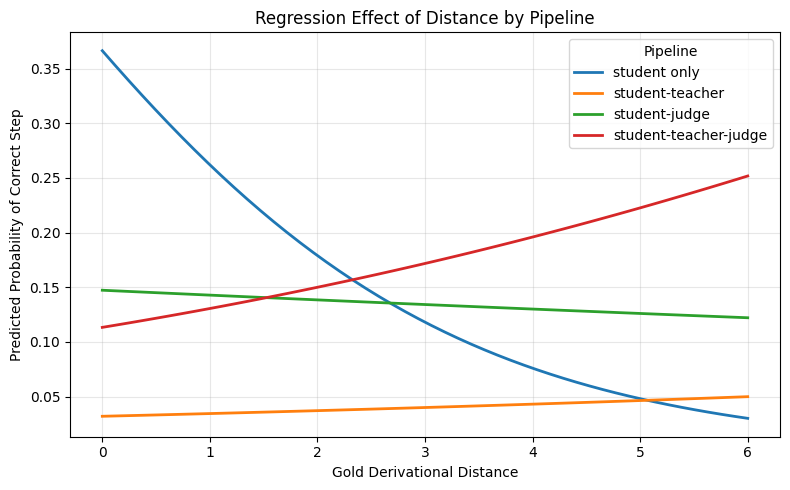

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pipelines = df_all['pipeline'].unique()

distance_range = np.linspace(
    df_all['KG_distance'].min(),
    df_all['KG_distance'].max(),
    50
)

mean_complexity = df_all['KG_complexity'].mean()

plot_rows = []
for p in pipelines:
    for d in distance_range:
        plot_rows.append({
            'pipeline': p,
            'KG_distance': d,
            'KG_complexity': mean_complexity
        })

plot_df = pd.DataFrame(plot_rows)

# Predict probabilities from fitted model
plot_df['pred_prob'] = model.predict(plot_df)

plt.figure(figsize=(8, 5))
for p in pipelines:
    subset = plot_df[plot_df['pipeline'] == p]
    plt.plot(
        subset['KG_distance'],
        subset['pred_prob'],
        label=p,
        linewidth=2
    )

plt.xlabel("Gold Derivational Distance")
plt.ylabel("Predicted Probability of Correct Step")
plt.title("Regression Effect of Distance by Pipeline")
plt.legend(title="Pipeline")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


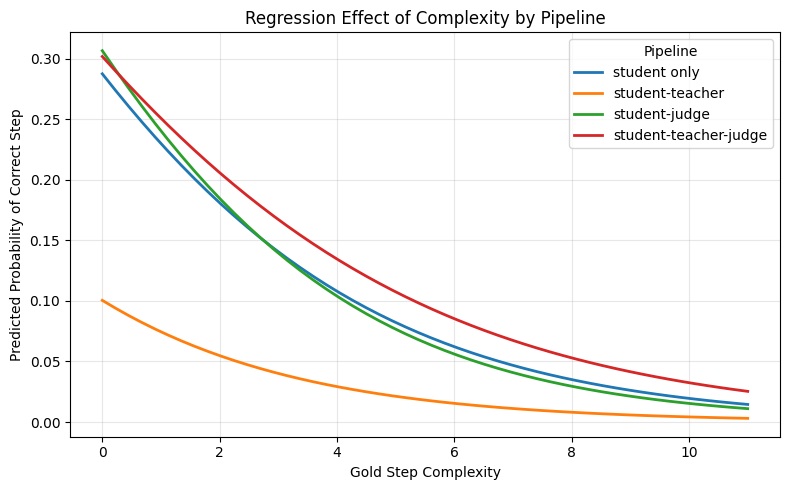

In [42]:
complexity_range = np.linspace(
    df_all['KG_complexity'].min(),
    df_all['KG_complexity'].max(),
    50
)

mean_distance = df_all['KG_distance'].mean()

plot_rows = []
for p in pipelines:
    for c in complexity_range:
        plot_rows.append({
            'pipeline': p,
            'KG_complexity': c,
            'KG_distance': mean_distance
        })

plot_df = pd.DataFrame(plot_rows)
plot_df['pred_prob'] = model.predict(plot_df)

plt.figure(figsize=(8, 5))
for p in pipelines:
    subset = plot_df[plot_df['pipeline'] == p]
    plt.plot(
        subset['KG_complexity'],
        subset['pred_prob'],
        label=p,
        linewidth=2
    )

plt.xlabel("Gold Step Complexity")
plt.ylabel("Predicted Probability of Correct Step")
plt.title("Regression Effect of Complexity by Pipeline")
plt.legend(title="Pipeline")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


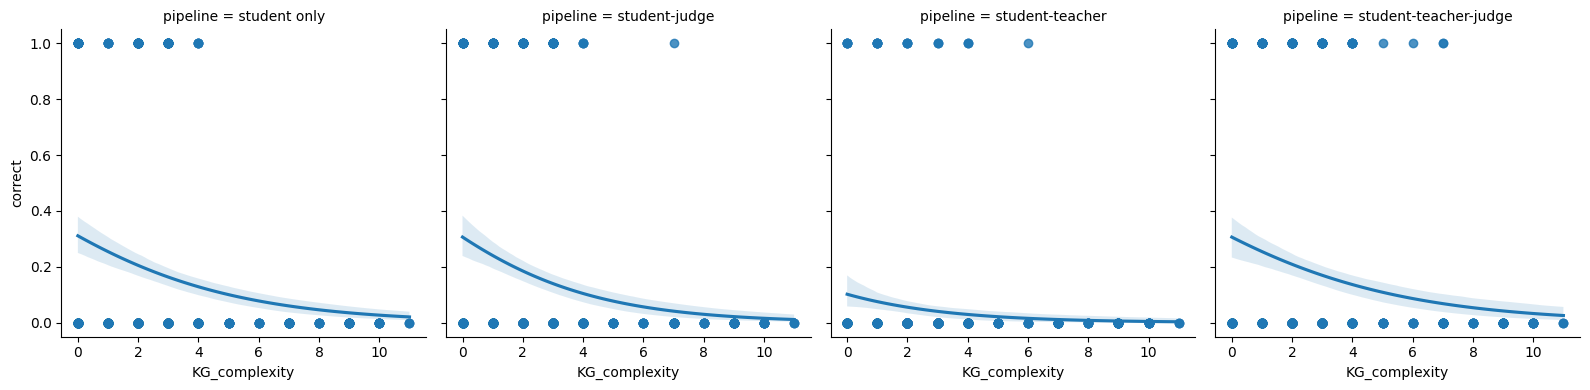

In [43]:
import seaborn as sns

sns.lmplot(
    data=df_all,
    x="KG_complexity",
    y="correct",
    col="pipeline",
    logistic=True,
    ci=95,
    height=4,
    aspect=1
)


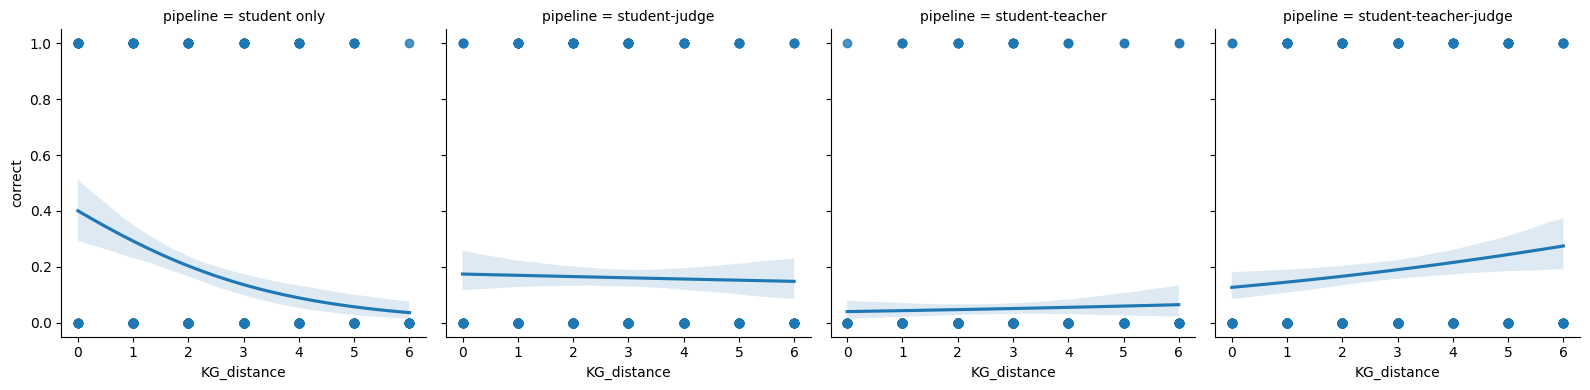

In [44]:
import seaborn as sns

sns.lmplot(
    data=df_all,
    x="KG_distance",
    y="correct",
    col="pipeline",
    logistic=True,
    ci=95,
    height=4,
    aspect=1
)


# Regression for student details 

In [45]:
# add student_complexity, student_depth, student_distance from df to df_student, df_teacher, df_judge, df_teacher_judge
df_student_1= pd.concat([df_student, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)
df_teacher_1 = pd.concat([df_teacher, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)
df_judge_1 = pd.concat([df_judge, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)
df_teacher_judge_1 = pd.concat([df_teacher_judge, df[['student_complexity', 'student_depth', 'student_distance']]], axis=1)

# Safe function to evaluate literal expressions - handles both strings and already-parsed lists
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            # If literal_eval fails (e.g., contains comparison operators), return empty list
            return []
    elif isinstance(x, (list, tuple)):
        return x
    else:
        return x

df['known_expressions'] = df['known_expressions'].apply(safe_literal_eval)
df['known_expressions_length'] = df['known_expressions'].apply(len)
df['student_parent_statements'] = df['student_parent_statements'].apply(safe_literal_eval)
df['parents_length'] = df['student_parent_statements'].apply(len)
df['student_parent_complexity'] = df['student_parent_complexities'].apply(lambda x: sum(ast.literal_eval(x) if isinstance(x, str) else x))
df['student_parent_complexity'] = df['student_parent_complexities'].apply(sum)


# Now add this to all dataframes
df_student_1['known_expressions'] = df['known_expressions_length']
df_teacher_1['known_expressions'] = df['known_expressions_length']
df_judge_1['known_expressions'] = df['known_expressions_length']
df_teacher_judge_1['known_expressions'] = df['known_expressions_length']

df_student_1['parents_length'] = df['parents_length']
df_teacher_1['parents_length'] = df['parents_length']
df_judge_1['parents_length'] = df['parents_length']
df_teacher_judge_1['parents_length'] = df['parents_length']

df_student_1['parent_complexity'] = df['student_parent_complexity']
df_teacher_1['parent_complexity'] = df['student_parent_complexity']
df_judge_1['parent_complexity'] = df['student_parent_complexity']
df_teacher_judge_1['parent_complexity'] = df['student_parent_complexity']


df_student.head()
df_all_1 = pd.concat([df_student_1, df_teacher_1, df_judge_1, df_teacher_judge_1])
print(df_all_1.shape)
df_all_1.head()

# Regression for student details 
# add student_complexity, student_depth, student_distance from to df_student

(2024, 12)


,id,KG_complexity,KG_distance,correct,model,pipeline,student_complexity,student_depth,student_distance,known_expressions,parents_length,parent_complexity
0,2,1,3,0,GPT-4.1,student only,2,3.0,7,3,1,2
1,3,0,0,1,GPT-4.1,student only,0,1.0,3,6,2,2
2,4,3,2,1,GPT-4.1,student only,2,1.0,3,4,2,10
3,6,2,1,1,GPT-4.1,student only,2,1.0,1,5,2,12
4,7,3,2,1,GPT-4.1,student only,2,1.0,3,5,2,1


In [46]:
df_all_1['pipeline'].unique()

array(['student only', 'student-teacher', 'student-judge',
       'student-teacher-judge'], dtype=object)

In [47]:
formula_interaction = """
correct ~ pipeline + KG_complexity + KG_distance + 
          pipeline:KG_complexity + pipeline:KG_distance

"""
result = smf.logit(
    formula=formula_interaction,
    data=df_all_1
).fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.366510
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 2024
Model:                          Logit   Df Residuals:                     2012
Method:                           MLE   Df Model:                           11
Date:                Sun, 28 Dec 2025   Pseudo R-squ.:                  0.1099
Time:                        17:33:31   Log-Likelihood:                -741.82
converged:                       True   LL-Null:                       -833.40
Covariance Type:            nonrobust   LLR p-value:                 2.280e-33
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         

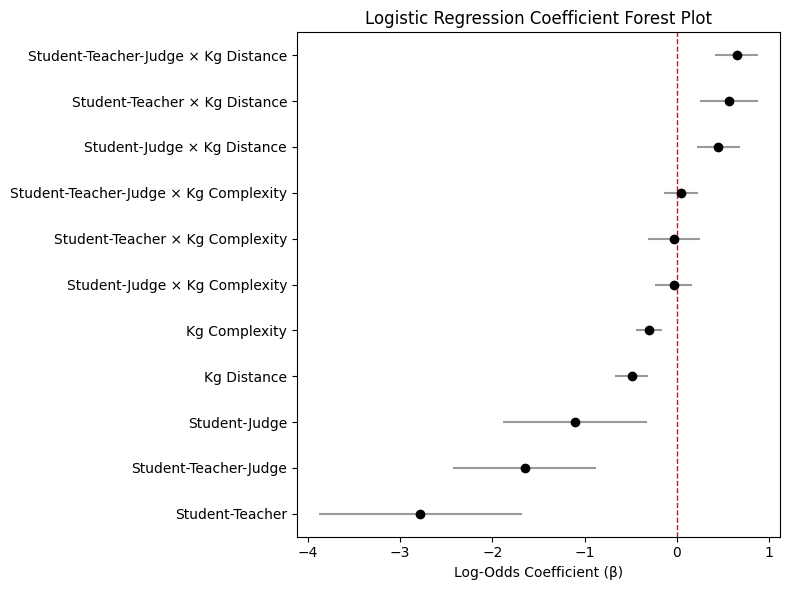

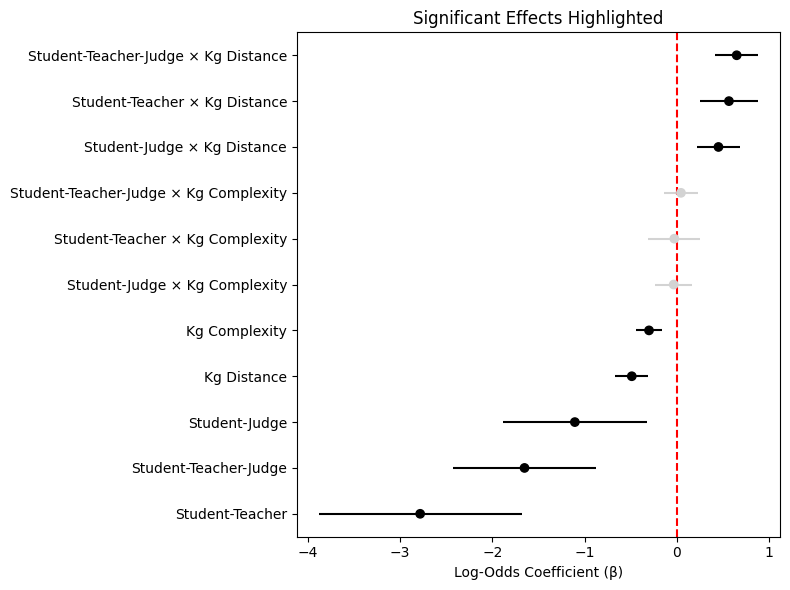

In [48]:
# Extract coefficients from statsmodels
import pandas as pd
import numpy as np

# Extract coefficients
coef_df = pd.DataFrame({
    "term": result.params.index,
    "coef": result.params.values,
    "ci_low": result.conf_int()[0].values,
    "ci_high": result.conf_int()[1].values,
    "p_value": result.pvalues.values
})

# Remove intercept (usually not informative in forest plots)
coef_df = coef_df[coef_df["term"] != "Intercept"]

# Optional: sort for nicer plotting
coef_df = coef_df.sort_values("coef")

# Clean up term names (important for paper quality)
def pretty_term(term):
    term = term.replace("pipeline[T.", "")
    term = term.replace("]", "")
    term = term.replace(":", " × ")
    term = term.replace("_", " ")
    return term.title()

coef_df["term_pretty"] = coef_df["term"].apply(pretty_term)

# Draw the coefficient forest plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot confidence intervals
plt.hlines(
    y=coef_df["term_pretty"],
    xmin=coef_df["ci_low"],
    xmax=coef_df["ci_high"],
    color="gray",
    alpha=0.8
)

# Plot point estimates
plt.scatter(
    coef_df["coef"],
    coef_df["term_pretty"],
    color="black",
    zorder=3
)

# Vertical zero line
plt.axvline(0, color="red", linestyle="--", linewidth=1)

plt.xlabel("Log-Odds Coefficient (β)")
plt.ylabel("")
plt.title("Logistic Regression Coefficient Forest Plot")

plt.tight_layout()
plt.show()


# Highlight statistically significant effects (optional but recommended)
sig = coef_df["p_value"] < 0.05

plt.figure(figsize=(8, 6))

plt.hlines(
    coef_df["term_pretty"],
    coef_df["ci_low"],
    coef_df["ci_high"],
    color=["black" if s else "lightgray" for s in sig]
)

plt.scatter(
    coef_df["coef"],
    coef_df["term_pretty"],
    c=["black" if s else "lightgray" for s in sig],
    zorder=3
)

plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Log-Odds Coefficient (β)")
plt.title("Significant Effects Highlighted")
plt.tight_layout()
plt.show()




In [49]:
model_clustered = smf.logit(
    formula=formula_interaction,
    data=df_all_1
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_all_1["id"]}
)

print(model_clustered.summary())


Optimization terminated successfully.
         Current function value: 0.366510
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 2024
Model:                          Logit   Df Residuals:                     2012
Method:                           MLE   Df Model:                           11
Date:                Sun, 28 Dec 2025   Pseudo R-squ.:                  0.1099
Time:                        17:33:31   Log-Likelihood:                -741.82
converged:                       True   LL-Null:                       -833.40
Covariance Type:              cluster   LLR p-value:                 2.280e-33
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         